# init

In [1]:
PDF_export_active = False

In [2]:
import sled_ROI_tools
import sled_general_tools
import sled_stat_tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os
import sys
import jsimg as jsi
import ttracking as tt
import js_manuscript as jsm
import copy
import glob
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import ttest_ind
from matplotlib import animation
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
import matplotlib as mpl
from scipy import stats
import importlib
import time
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42


In [3]:
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig6"

mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
#mdTitle = 'atLeast1postShift_perAnatRecd_slim2'
#mdTitle = f'atLeast1postShift_anyAnat_slim3'
mdTitle = 'allSlim3'
masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

In [4]:
dffKeys = ['consensus_NMFtc_dff_bc_decon_sp_events']
factors = [10,5]
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
windowSize = []
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys)

0 B00002121749
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:172: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:427: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:513: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:517: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


relDays: [-8 -2  0  2  5]
phase: preShift_late, days used: [-2  0]
phase: early, days used: [0, 2]
1 B00002121774
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:172: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:427: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:513: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:517: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285
relDays: [-6 -5 -4 -3  0  1  2  3  8]
phase: preShift_early, days used: [-5 -4]
phase: preShift_late, days used: [-3  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


...

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:172: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:427: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:513: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:517: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2  3  4]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]
21 B00002214001
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:427: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:513: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:517: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
relDays: [-4 -3 -2 -1  0  1  2  3  4]
phase: preShift_early, days used: [-3 -2]
phase: preShift_late, days used: [-1  0]
phase: late, days used: [2 3]
phase: early, days used: [0, 1]


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/ttracking.py:1781: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


# pre post

### preCalc

In [5]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
thrsh = 0.05
minTrials = 10
anatKeys = ['dendrites', 'somas']
importlib.reload(jsm)
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213943 311 340 24 50
dendrites B00002213998 366 28 148 17
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 256 18
somas B00002213999 287 207 15 12
12


In [6]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
iAnms = {}
aAnms = {}
minTrials = 100
anmsMinTrial = {}
for anat in anatKeys:
    iAnms[anat] = []
    aAnms[anat] = []
    anmsMinTrial[anat] = {}
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            preCR = np.sum(pretkr[:,2]==0)
            preCL = np.sum(pretkr[:,2]==1)
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if np.all(np.hstack([item>minTrials for item in [pCR, pCL, preCR, preCL]])):
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms[anat].append(anm)
                        print(anat, anm, np.sum(pCR),np.sum(pCL))
                        anmsMinTrial[anat][anm] = np.min(np.hstack([pCR, pCL, preCR, preCL]))
print(iAnms)

dendrites B00002121774 295 244
dendrites B00002213772 311 199
dendrites B00002213784 377 254
dendrites B00002213785 166 141
dendrites B00002213908 178 138
dendrites B00002213920 245 226
dendrites B00002213932 253 210
dendrites B00002213970 130 294
dendrites B00002213982 170 175
dendrites B00002213985 248 250
dendrites B00002213997 228 177
dendrites B00002213999 365 268
somas B00002121774 237 224
somas B00002213772 432 223
somas B00002213784 243 180
somas B00002213785 166 140
somas B00002213889 226 139
somas B00002213908 336 222
somas B00002213920 229 199
somas B00002213982 225 200
somas B00002213999 276 190
somas B00002214001 161 199
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213920', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213985', 'B00002213997', 'B00002213999'], 'somas': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213889', 'B00002213908', 'B00002213920', 'B00002213982', 'B0000221399

In [7]:
iAnms2 = {}
aAnms2 = {}
minTrials = 10
for anat in anatKeys:
    iAnms2[anat] = []
    aAnms2[anat] = []
    for anm in anms:
        if anat in list(allAnmParams[anm][dffKey]['dsTsep'].keys()):
            aAnms2[anat].append(anm)
            tracker = allAnmParams[anm]['tracker']
            dendDays = allAnmParams[anm]['dendDays']
            cTimes = allAnmParams[anm]['cTimes']
            goCues = allAnmParams[anm]['goCues']
            preMask = allAnmParams[anm]['shiftMask']['pre']
            postMask = allAnmParams[anm]['shiftMask']['post']
            earlyMask = allAnmParams[anm]['shiftMask']['early']
            lateMask = allAnmParams[anm]['shiftMask']['late']
            me = allAnmParams[anm]['me']
            de = allAnmParams[anm]['de']
            ar = allAnmParams[anm]['afterRight']
            al = allAnmParams[anm]['afterLeft']
            an = allAnmParams[anm]['afterNone']
            ln = np.logical_or(al, an)

            if anat == 'dendrites':
                anatMask = dendDays
            else:
                anatMask = ~dendDays

            preAnatMask = np.logical_and(anatMask, preMask)
            postAnatMask = np.logical_and(anatMask, postMask)
            pretkr = tracker[preAnatMask,:]
            posttkr = tracker[postAnatMask,:]
            postME = me[postAnatMask]
            postDE = de[postAnatMask]
            postAR = ar[postAnatMask]
            postAL = al[postAnatMask]
            postAN = an[postAnatMask]
            postLN = ln[postAnatMask]
            
            pCR = np.sum(posttkr[:,2]==0)
            pCL = np.sum(posttkr[:,2]==1)
            pMER = np.sum(np.logical_and(postME, posttkr[:,2]==5))
            pDER = np.sum(np.logical_and(postDE, posttkr[:,2]==5))
            pAR = np.sum(postAR)
            pAL = np.sum(postAL)
            pAN = np.sum(postAN)
            pNL = np.sum(postLN)
            
            ftsep = allAnmParams[anm][dffKey]['fullTsep'][anat]['full']
            dsTsep = allAnmParams[anm][dffKey]['dsTsep'][anat]['full']

            if pAR>minTrials and pCR>minTrials:# and pAL>minTrials:# and anmLearn[anm]==(1,0,0):
            #if pMER>minTrials and pCR>minTrials:
                if anm != 'B00002121777':
                    if ftsep.shape[1]>=10:
                        iAnms2[anat].append(anm)
                        print(anat, anm, np.sum(pAR), np.sum(pAL), np.sum(pCR))
print(iAnms2)

dendrites B00002121774 93 4 295
dendrites B00002213772 31 17 311
dendrites B00002213784 26 5 377
dendrites B00002213785 44 17 166
dendrites B00002213908 36 42 178
dendrites B00002213932 66 19 253
dendrites B00002213970 269 195 130
dendrites B00002213982 176 98 170
dendrites B00002213997 295 35 228
dendrites B00002213998 202 50 233
dendrites B00002213999 86 54 365
somas B00002121749 25 25 113
somas B00002121774 160 17 237
somas B00002213772 29 35 432
somas B00002213784 28 8 243
somas B00002213889 16 7 226
somas B00002213908 53 21 336
somas B00002213982 108 5 225
somas B00002213985 29 4 143
somas B00002213997 124 14 169
somas B00002213999 47 64 276
somas B00002214001 78 32 161
{'dendrites': ['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785', 'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982', 'B00002213997', 'B00002213998', 'B00002213999'], 'somas': ['B00002121749', 'B00002121774', 'B00002213772', 'B00002213784', 'B00002213889', 'B00002213908', 'B00002213982', 'B

In [8]:
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')

dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8


In [9]:
bothAnms = {}
for ak, anat in enumerate(anatKeys):
    anms1 = iAnms[anat]
    anms2 = iAnms2[anat]
    print(anat, f'MER {len(anms1)}', f'Motor {len(anms2)}', f'Both {np.sum(np.isin(anms1, anms2))}')
    bothAnms[anat] = np.hstack(anms1)[np.isin(anms1, anms2)]
bothAnms

dendrites MER 12 Motor 11 Both 10
somas MER 10 Motor 11 Both 8


{'dendrites': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213785',
        'B00002213908', 'B00002213932', 'B00002213970', 'B00002213982',
        'B00002213997', 'B00002213999'], dtype='<U12'),
 'somas': array(['B00002121774', 'B00002213772', 'B00002213784', 'B00002213889',
        'B00002213908', 'B00002213982', 'B00002213999', 'B00002214001'],
       dtype='<U12')}

In [10]:
psWindow = [-3.6,3.6]
useDS = True
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
#anmsToUse = iAnms
anmsToUse = bothAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = True
binary = False

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre', 'post']
pLabels = ['pre', 'post']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']

nBoot = 10000
megaTseps = {}
megaTsepsHH = {}
emptyMegaTsep = {'dendrites': [], 'somas': []}

for p, phase in enumerate(phases):
    megaTseps[phase] = {}
    megaTsepsHH[f'{phase}1'] = {}
    megaTsepsHH[f'{phase}2'] = {}
    for mod in mods:
        megaTseps[phase][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}1'][mod] = copy.deepcopy(emptyMegaTsep)
        megaTsepsHH[f'{phase}2'][mod] = copy.deepcopy(emptyMegaTsep)

#making holder matracies
somaTime = allAnmParams[anmsToUse['somas'][0]][dffKey]['dsTsep']['somas']['go-psTsep'].shape[2]
nSoma = 0
for anm in anmsToUse['somas']:
    nSoma+=allAnmParams[anm][dffKey]['dsTsep']['somas']['go-psTsep'][:,keepRoisDS['somas'][anm],:].shape[1]
    
dendTime = allAnmParams[anmsToUse['dendrites'][0]][dffKey]['dsTsep']['dendrites']['go-psTsep'].shape[2]
nDend = 0
for anm in anmsToUse['dendrites']:
    nDend+=allAnmParams[anm][dffKey]['dsTsep']['dendrites']['go-psTsep'][:,keepRoisDS['dendrites'][anm],:].shape[1]

somaEmpty = np.empty([4, somaTime, nSoma, nBoot])
dendEmpty = np.empty([4, dendTime, nDend, nBoot])
empties = [dendEmpty, somaEmpty]
for phase in phases:
    for mod in mods:
        for ak, anat in enumerate(anatKeys):
            megaTseps[phase][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}1'][mod][anat] = copy.deepcopy(empties[ak])
            megaTsepsHH[f'{phase}2'][mod][anat] = copy.deepcopy(empties[ak])    
for i in tqdm(range(nBoot)):
    for ak, anat in enumerate(anatKeys):
        if shuffAnms:
            anmIdxs = np.random.choice(np.arange(len(anmsToUse[anat])), len(anmsToUse[anat]))
        else:
            anmIdxs = np.arange(len(anmsToUse[anat]))
        nRois = np.sum(np.hstack([np.sum(keepRoisDS[anat][anm]) for anm in anmsToUse[anat]]))
        for m, mod in enumerate(mods):
            if 'err' in mod:
                returnErrors = True
            else:
                returnErrors = False
            
            mT = jsm.gather_anmShuff_megaTsepFull(allAnmParams, anat, ak, mod, phases, frs, keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            
            mT1, mT2 = jsm.gather_anmShuff_megaTsepHH(allAnmParams, anat, ak, mod, phases, frs,  keepRoisDS, dffKey, alignTimes[m], anmsToUse, nRois,
                                                  anmIdxs, enforceMinTrial, binary, returnErrors, anmsMinTrial)
            for phase in phases:
                megaTseps[phase][mod][anat][:,:,:,i] = mT[phase]
                megaTsepsHH[f'{phase}1'][mod][anat][:,:,:,i] = mT1[phase]
                megaTsepsHH[f'{phase}2'][mod][anat][:,:,:,i] = mT2[phase]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [11]:
for ak, anat in enumerate(anatKeys):
    print(anat, megaTsepsHH[f'{phases[0]}2'][mod][anat].shape)

dendrites (4, 32, 167, 10000)
somas (4, 34, 179, 10000)


In [12]:
for anat in anatKeys:
    print(anat, len(bothAnms[anat]))

dendrites 10
somas 8


In [13]:
nBoot = 10000

allAnmCDs = {}
allAnmDenoms = {}
allAnmIdxs = {}
takeEqualTrials = True
anmsToUse = bothAnms
for ak, anat in enumerate(anatKeys):
    allAnmCDs[anat] = {}
    allAnmDenoms[anat] = {}
    allAnmIdxs[anat] = []
    F = frs[ak]/factors[ak]
    for a, anm in enumerate(anmsToUse[anat]):
        print(anm+" "+anat)
        nROI = np.sum(keepRoisDS[anat][anm])
        allAnmIdxs[anat].append(np.ones(nROI)*a)
        allAnmCDs[anat][anm] = {}
        allAnmDenoms[anat][anm] = {}
        nTriToGrab=[]
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]

            nTriToGrab.append(np.min([np.sum(clM), np.sum(crM)]))
        nTriToGrab=np.min(nTriToGrab)
        
        for phase in ['pre','post']:
    
            anmData = allAnmParams[anm]
            tsep = anmData[dffKey]['dsTsep'][anat]['go-psTsep']
            sMask = anmData['shiftMask'][phase]
            dd = anmData['dendDays']
            if anat == 'dendrites':
                anatMask = dd
            else:
                anatMask = ~dd
            tracker = anmData['tracker']
            fullMask = np.logical_and(anatMask, sMask)
            roiMask = keepRoisDS[anat][anm]
            
            pTkr = tracker[fullMask,:]
            crM = pTkr[:,2]==0
            crT = np.where(crM)[0]

            clM = pTkr[:,2]==1
            clT = np.where(clM)[0]
            
            pTsep = tsep[fullMask[anatMask],:,:]
            pTsep = pTsep[:,roiMask,:]            
            CDs = []
            denoms = []
            for i in tqdm(range(nBoot)):
                if takeEqualTrials:
                    bCRm = np.random.choice(crT, nTriToGrab)
                    bCLm = np.random.choice(clT, nTriToGrab)
                else:
                    bCLm = np.random.choice(clT, len(clT))
                    bCRm = np.random.choice(crT, len(crT))
                CR = np.nanmean(pTsep[bCRm,:,:], axis = 0)
                CL = np.nanmean(pTsep[bCLm,:,:], axis = 0)
                denom = np.abs((np.nanmean(pTsep[bCRm,:,:],axis = 0))+np.abs(np.nanmean(pTsep[bCLm,:,:],axis = 0)))
                cd = (CR-CL)/denom
                CDs.append(cd)
                denoms.append(denom)
            CDs = np.stack(CDs)
            denoms = np.stack(denoms)#boot x roi x time
            allAnmCDs[anat][anm][phase] = CDs
            allAnmDenoms[anat][anm][phase] = denoms
    allAnmIdxs[anat] = np.hstack(allAnmIdxs[anat])

B00002121774 dendrites


  0%|          | 0/10000 [00:00<?, ?it/s]

/tmp/ipykernel_63622/2646086421.py:84: RuntimeWarning: invalid value encountered in true_divide
  cd = (CR-CL)/denom


  0%|          | 0/10000 [00:00<?, ?it/s]

B00002213772 dendrites


...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

B00002214001 somas


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

## CRCL HH Scroll

In [14]:
%%time
importlib.reload(jsm)
nBoots = 10000
CRCL_HHscroll = {}
for ak, anat in enumerate(anatKeys):
    CRCL_HHscroll[anat] = {}
    for calcPhase in ['pre1','pre2','post1', 'post2']:
        CRCL_HHscroll[anat][calcPhase] = {}
        for m, mod in enumerate(['CT','GO']):#,'LL']):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_CRCL_CD_fast(megaTsepsHH,anat, mod, calcPhase, nBoots)
            CRCL_HHscroll[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre1 CT
starting dendrites pre1 GO
starting dendrites pre2 CT
starting dendrites pre2 GO
starting dendrites post1 CT
starting dendrites post1 GO
starting dendrites post2 CT
starting dendrites post2 GO
starting somas pre1 CT
starting somas pre1 GO
starting somas pre2 CT
starting somas pre2 GO
starting somas post1 CT
starting somas post1 GO
starting somas post2 CT
starting somas post2 GO
done
CPU times: user 1min 25s, sys: 49 s, total: 2min 14s
Wall time: 2min 15s


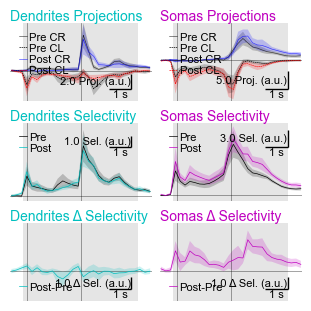

In [15]:

figName = 'Fig6_projections.pdf'
figSize = [3,3]
nRows= 3
nCols = 2
fig, axs = sled_general_tools.clean_subplots(nRows,nCols,figSize, sharex = True, constrained_layout = True)
fontsize = 8
labels = ['Pre','Post','Post-Pre']# 'postPost']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
colors = [(0,0,0),(0,1,0),'']
preColor = (0,0,0)
preColors = [(0,0,0),(0,0,0)]
postColors = [(0,0,1),(1,0,0)]
preLS = [':','--']
postLS = ['-','-']
preDashes = [(1, 0.5), (2, 1)]
postDashes = [(1, 0.5), (2, 1)]
trialLabels = ['CR', 'CL','MER','DER']
niceAnatLabels = ['Dendrites', 'Somas']
offsets = [5,10]
allDifs = {}
allSels = {}
xlim = [-3.2,3.2]
xticks = np.arange(7)-3
ylims1 = [[-4,6.2],[-11,10]]
ylims2 = [[-0.5,7],[-1,13]]
ylims3 = [[-2.5,4],[-2.5,4]]
window = [3.6,3.6+2.6]
plotLims = [-3.6,3.6]
linewidth = 0.5
mod = 'GO'
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boot. mean±SEM"
elif error == 'std':
    errorLabel = "boot. mean±SD"
if mod == 'GO':
    alignTime = 'Go Cue'
    markers = [0,-1.25,-2.45]
    markers = [0,-2.45]
else:
    alignTime = 'Contact'
    markers = [0]

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.25
plot_scaleBar['lw'] = 1
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

for ak, anat in enumerate(anatKeys):
    pre = CRCL_HHscroll[anat]['pre1'][mod]['projs']['pre2'] #boot, time, trial
    preSel = pre[:,0,:]-pre[:,1,:]
    
    post = CRCL_HHscroll[anat]['post1'][mod]['projs']['post2']
    postSel = post[:,0,:]-post[:,1,:]

    
    allSels[anat] = {}
    allSels[anat]['pre'] = preSel
    allSels[anat]['post'] = postSel
    
    dif = postSel - preSel
    allDifs[anat] = dif

    ax = axs[1,ak]
    sels = [preSel,postSel]
    traces = [pre,post,dif]

    titles2 = ['Projections', 'Selectivity','Δ Selectivity']
    titles3 = ['Proj.', 'Sel.','Δ Sel.']
    for a, ax in enumerate(axs[:,ak]):
        if a == 0:
            ax.set_ylim(ylims1[ak])
            plot_scaleBar['vertAdjust']=0.15
        elif a == 1:
            ax.set_ylim(ylims2[ak])
            plot_scaleBar['vertAdjust']=0.7
        elif a == 2:
            ax.set_ylim(ylims3[ak])
            plot_scaleBar['vertAdjust']=0.15

        ylim = ax.get_ylim()
        ax.text(xlim[0],ylim[1],niceAnatLabels[ak]+" "+titles2[a],color=aColors[ak],fontsize=fontsize+2,ha='left',va='bottom')

            
        for mark in markers:
            ax.plot([mark]*2,ylim,lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
        ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)

        ax.fill_between(np.hstack([-2.6, 2.6]), ylim[0], ylim[1], color = (0,0,0), alpha = 0.1, edgecolor='none')

        vertLabel = titles3[a]+' (a.u.)\n('+errorLabel+')'
        vertLabel = titles3[a]+' (a.u.)'

        ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)

    for p in [0,1]:
        row = 0
        ax = axs[row,ak]
        for t in range(2):
            data = traces[p][:,t,:]
            if p == 0:
                color = (0,0,0)
            else:
                color = postColors[t]
            mean = np.nanmean(data,axis=0)
            med = np.nanmedian(data,axis=0)
            std = np.nanstd(data,axis=0, ddof = 1)
            sem = std / np.sqrt(data.shape[0])
            low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
            x = np.linspace(plotLims[0],plotLims[1],len(mean))
            plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
            if error == 'CI':
                mainPlot = med
                errorLow = low
                errorHigh = high
            elif error == 'sem':
                mainPlot = mean
                errorLow = mean-sem
                errorHigh = mean+sem
            elif error == 'std':
                mainPlot = mean
                errorLow = mean-std
                errorHigh = mean+std
            if p == 1:
                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = postColors[t], alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = postLS[t], color = postColors[t], label = "Post "+trialLabels[t],lw=linewidth,dashes=postDashes[t])
            else:
                ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = preColors[t], alpha = 0.2, edgecolor='none')
                ax.plot(x[plotIdx], mainPlot[plotIdx], ls = preLS[t], color = preColors[t], label =  "Pre "+trialLabels[t],lw=linewidth,dashes=preDashes[t])
        ax.set_xlim(xlim)
        ax.set_ylim(ylims1[ak])
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',\
                   handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

        row = 1
        ax = axs[row,ak]
        data = sels[p]
        lss = ['-','-']
        mean = np.nanmean(data,axis=0)
        med = np.nanmedian(data,axis=0)
        std = np.nanstd(data,axis=0, ddof = 1)
        sem = std / np.sqrt(data.shape[0])
        low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        x = np.linspace(plotLims[0],plotLims[1],len(mean))
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        if error == 'CI':
            mainPlot = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot = mean
            errorLow = mean-std
            errorHigh = mean+std
        if p == 1:
            ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.2, edgecolor='none')
            ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[p], color = aColors[ak], label = labels[p],lw=linewidth)
        else:
            ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = preColor, alpha = 0.2, edgecolor='none')
            ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[p], color = preColor, label = labels[p],lw=linewidth)
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',\
                   handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
        ax.set_xlim(xlim)
        ax.set_ylim(ylims2[ak])

    row = 2
    ax = axs[row,ak]
    data = dif
    lss = ['-']
    mean = np.nanmean(data,axis=0)
    med = np.nanmedian(data,axis=0)
    std = np.nanstd(data,axis=0, ddof = 1)
    sem = std / np.sqrt(data.shape[0])
    low,high = np.nanpercentile(data, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
    x = np.linspace(plotLims[0],plotLims[1],len(mean))
    plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std
    ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.2, edgecolor='none')
    ax.plot(x[plotIdx], mainPlot[plotIdx], ls = lss[0], color = aColors[ak], label = labels[row],lw=linewidth)
    ax.legend(frameon=False,fontsize=fontsize,loc='lower left',\
               handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 
    ax.set_xlim(xlim)
    ax.set_ylim(ylims3[ak])

        
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)


if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)

dendrites mean: -3.041 std: 10.058 pVal: 0.722
somas mean: 32.259 std: 7.659 pVal: 0.000
anat comp 0.003
Bbox(x0=0.125, y0=0.10999999999999999, x1=0.9, y1=0.88)


/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


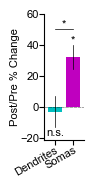

In [16]:
figName = 'Fig6_selectivity_perChange.pdf'
fontsize = 8
figsize = [0.5,1.4]
fig, ax = sled_general_tools.clean_subplots(1,1,figsize=figsize,facecolor='none',constrained_layout = False)
pColors = [(1,0,0),(0,1,0),(0,0,0)]
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
barwidth = 0.1
pLabels = ['Early', 'Late','Late-Early']
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"

testLine = 0
niceAnatLabels = ['Dendrites','Somas']
window = [1,6.2]
plotLims = [-3.6,3.6]
allDists = {}
allPs = {}
alphas = [0.3,0.6]
ylim = [-21,60]
testLS = ':'
testLW = 0.5
testColor = (0,0,0)
testAlpha = 0.5
testDashes = (5,1)

ax.spines[['top','right']].set_visible(False)
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha,dashes=testDashes)
ax.set_ylim(ylim)
for ak, anat in enumerate(anatKeys):
    allPs[anat] = {}
    F = frs[ak]/factors[ak]
    pre = allSels[anat]['pre']
    preMean = np.nanmean(pre[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    post = allSels[anat]['post']
    postMean = np.nanmean(post[:,int(window[0]*F):int(window[1]*F)], axis = 1)
    #ratio = post/pre
    ratio = postMean/preMean
    wData = (ratio-1)*100#ratio
    wData = (postMean-preMean)/np.absolute(preMean)*100#ratio
    allDists[anat] = wData

    mean = np.nanmean(wData,axis=0)
    med = np.nanmedian(wData,axis=0)
    std = np.nanstd(wData,axis=0, ddof = 1)
    sem = std / np.sqrt(wData.shape[0])
    low,high = np.nanpercentile(wData, [100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std

    testLine = 0
        
    tail1 = np.sum(wData<testLine)/wData.shape[0]
    tail2 = np.sum(wData>testLine)/wData.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    pText = sled_stat_tools.pstar(pVal,inclP = False)

    allPs[anat]=pVal
    print(anat, f'mean: {np.nanmean(wData):.03f}', f'std: {np.nanstd(wData):.03f}', f'pVal: {pVal:.03f}')
    
    x = ak/4
    ax.bar(x, mainPlot, width = 0.2, color = aColors[ak], alpha = 1)
    ax.plot([x,x],[errorLow,errorHigh],color = (0,0,0),lw = linewidth)
    if mainPlot<testLine:
        text_ypos = errorLow
        va='top'
    else:
        text_ypos = errorHigh
        va = 'bottom'

    ax.text(x, text_ypos, pText, fontsize=fontsize,ha='center',va=va)
                

dData = allDists['dendrites']
sData = allDists['somas']

pVal = np.sum(sData<dData)/wData.shape[0]
pText = sled_stat_tools.pstar(pVal,inclP = False)
print('anat comp', f'{pVal:.03f}')

topBarY = 50
ys = [topBarY,topBarY]
ax.plot([0,0.25],[ys[0],ys[0]], lw = linewidth, color = (0,0,0))
ax.text(.125,ys[0],pText,fontsize=fontsize,ha='center',va='bottom')
ax.set_xlim([-0.15,0.4])
ax.set_xticks([0,0.25])
ax.tick_params(axis='y', which='major', labelsize=fontsize) #

ax.set_ylabel('Post/Pre % Change',fontsize=fontsize,labelpad=0)
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize-2,rotation=30,ha='right',va='top',rotation_mode='anchor')
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
pos = ax.get_position()
print(pos)
ax.set_position([0.125,0,0.8,0.9])
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)